
## Project: Automated Product Classification from Descriptions

### Introduction

This project aims to develop a machine learning model capable of automatically classifying products into their respective categories based solely on their text descriptions. In the rapidly growing e-commerce landscape, manually tagging products is inefficient and prone to errors. By leveraging Natural Language Processing (NLP) techniques, we can create an intelligent system to automate this process.

This notebook will walk through the complete data science lifecycle: from data loading and cleaning of the unstructured text, through exploratory data analysis and feature engineering, to building, evaluating, and finally deploying a classification model as a web API.



**Dataset:** Product Description Dataset from Kaggle.
**Goal:** To accurately predict a `product_category` from a given `product_description`.

In [47]:
# Regular expressions library for text cleaning (e.g., removing special characters, numbers)
import re

# Pandas for loading and manipulating datasets (DataFrame structure)
import pandas as pd

# Stopwords list (common words like "the", "is") from NLTK for text preprocessing
from nltk.corpus import stopwords

# TF-IDF Vectorizer converts text into numerical feature vectors based on term frequency
from sklearn.feature_extraction.text import TfidfVectorizer

# Splits the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Multinomial Naive Bayes algorithm — commonly used for text classification
from sklearn.naive_bayes import MultinomialNB

# Functions to evaluate model performance (accuracy, classification report, confusion matrix)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Natural Language Toolkit — used here mainly to download resources (like stopwords)
import nltk

# Joblib for saving and loading trained models or transformers efficiently
import joblib

# Seaborn for visually appealing statistical plots (like heatmaps of confusion matrix)
import seaborn as sns

# Matplotlib for creating and customizing visualizations
import matplotlib.pyplot as plt

# Additional metrics to evaluate the model’s precision, recall, and F1-score
from sklearn.metrics import precision_score, recall_score, f1_score

In [48]:
import pandas as pd

# Use a try-except block to handle potential encoding errors in your specific CSV file
try:
    # Attempt to read the CSV file with standard UTF-8 encoding
    data = pd.read_csv("Articles.csv", encoding='utf-8')
except UnicodeDecodeError:
    # If UTF-8 fails, fall back to latin1 encoding
    print("UTF-8 encoding failed, trying latin1 encoding...\n")
    data = pd.read_csv("Articles.csv", encoding='latin1')

# Print a header relevant to your project
print("\n\nNews Articles Data:")
print("============\n")

# Print dataset size
print(f'Total number of articles in the dataset = {len(data)}\n')

# Show the first 5 rows of your dataset
print("First 5 articles:")
print(data.head(5))

UTF-8 encoding failed, trying latin1 encoding...



News Articles Data:

Total number of articles in the dataset = 2692

First 5 articles:
                                             Article      Date  \
0  KARACHI: The Sindh government has decided to b...  1/1/2015   
1  HONG KONG: Asian markets started 2015 on an up...  1/2/2015   
2  HONG KONG:  Hong Kong shares opened 0.66 perce...  1/5/2015   
3  HONG KONG: Asian markets tumbled Tuesday follo...  1/6/2015   
4  NEW YORK: US oil prices Monday slipped below $...  1/6/2015   

                                             Heading  NewsType  
0  sindh govt decides to cut public transport far...  business  
1                    asia stocks up in new year trad  business  
2           hong kong stocks open 0.66 percent lower  business  
3             asian stocks sink euro near nine year   business  
4                 us oil prices slip below 50 a barr  business  


In [49]:
import pandas as pd

# --- 1. Load Your Data (with encoding safety) ---
try:
    data = pd.read_csv("Articles.csv", encoding='utf-8')
except UnicodeDecodeError:
    data = pd.read_csv("Articles.csv", encoding='latin1')

# --- 2. Create the Balanced Sample ---

# Group the data by 'NewsType' and take 50 random samples from each category.
# The 'random_state' ensures you get the same random sample every time you run the code.
sample_data = data.groupby('NewsType').apply(lambda x: x.sample(n=50, random_state=42))

# Reset the index of the new DataFrame
sample_data = sample_data.reset_index(drop=True)


# --- 3. Display the Results ---

print("\n\nBalanced News Articles Sample:")
print("============================\n")

# Print the final counts for each category to show it's balanced
print("Distribution of articles in the new sample:")
print(sample_data['NewsType'].value_counts())

# Print the total number of samples
print(f'\nTotal samples in the balanced dataset = {len(sample_data)}\n')

# Display the entire balanced dataset (100 rows)
print("Preview of the balanced dataset:")
print(sample_data.head(100))



Balanced News Articles Sample:

Distribution of articles in the new sample:
NewsType
business    50
sports      50
Name: count, dtype: int64

Total samples in the balanced dataset = 100

Preview of the balanced dataset:
                                              Article        Date  \
0   strong>ISLAMABAD: The government has increased...   2/28/2017   
1   ISLAMABAD: National Electric Power Regulatory ...  10/22/2015   
2   strong>Grocery shopping can be fun or a chore ...   9/27/2016   
3   strong>NEW YORK/LONDON: Oil prices rose on Thu...    1/1/2016   
4   strong>KARACHI: Pakistan Stock Exchange witnes...   1/24/2017   
5   strong>ISLAMABAD: Pakistan Tourism Development...    8/8/2016   
6   LONDON: Global oil prices hit a new six and a ...   8/20/2015   
7   strong>DUBAI: It´s been an eventful few days f...   8/11/2016   
8   ISLAMABAD: The price of Liquefied Petroleum Ga...   9/23/2015   
9   strong>HONG KONG: Asian stocks held near three...    4/6/2016   
10  strong>ISLAMABA

C:\Users\HP\AppData\Local\Temp\ipykernel_17300\1533480246.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_data = data.groupby('NewsType').apply(lambda x: x.sample(n=50, random_state=42))


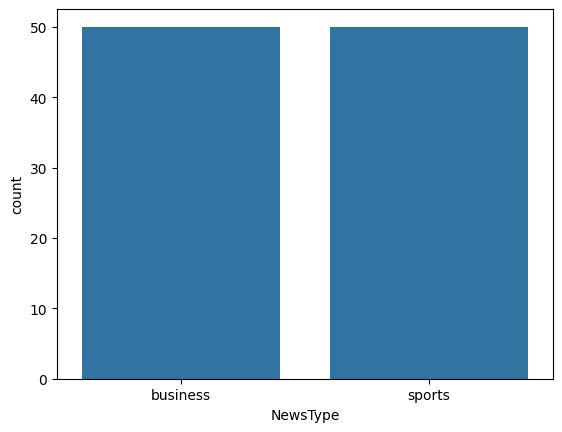

In [50]:
sns.countplot( x = 'NewsType', data = sample_data );

In [51]:
# save sample_data as .csv file
sample_data.to_csv("sample_news.csv", index=False)

In [52]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [53]:
# Create a set of English stopwords from NLTK.
# These are common words like "the", "is", "at", etc., which are usually removed
# because they don't add much meaning for sentiment classification.
# (Make sure you've run nltk.download('stopwords') once before this step.)
stop_words = set(stopwords.words('english'))

In [54]:
# Define a function to clean a single text string (one tweet at a time)
from nltk.corpus import stopwords

def clean_text(text):
    stop_words = set(stopwords.words('english'))
    # 1. Remove all characters that are NOT letters or whitespace.
    #    This strips out numbers, punctuation, emojis, and symbols.
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 2. Convert the entire text to lowercase.
    #    This makes comparisons uniform (e.g., "Good" and "good" become the same).
    text = text.lower()

    # 3. Remove stopwords from the text.
    #    Split the text into individual words,
    #    keep only words that are NOT in the stop_words set,
    #    and join the remaining words back into a single string.
    text = ' '.join(word for word in text.split() if word not in stop_words)

    # 4. Return the cleaned text.
    return text

In [80]:
# Load only the first 100 rows (tweets) from the CSV file into a DataFrame.
# 'nrows=100' instructs pandas to read only the top 100 rows.
# This is useful for quick testing or when the full dataset is very large.
data = pd.read_csv("sample_news.csv")

In [81]:
# Drop rows with NaN values in the text column
data = data.dropna(subset=['NewsType'])

In [82]:
# Sample data After Droping Rows with NAN Values
print(len(data))

100


In [83]:
# Apply the 'remove_symbols_numbers' function to every tweet in the 'tweet' column.
# This will strip out all numbers, punctuation, and symbols from each tweet.
# The cleaned tweets are then reassigned back into the same 'tweet' column.
#
# Using .loc[:, 'tweet'] avoids SettingWithCopyWarning by telling pandas
# you're explicitly modifying the original DataFrame column.
data.loc[:, 'NewsType'] = data['NewsType'].apply(clean_text)

In [84]:
# Print a header to indicate that the data shown below has been preprocessed.
print("\n\nSentiment Analysis Data After Preprocessing:")
print("=================================================\n")

# Configure pandas so it will display all rows and all columns of the DataFrame
# without truncating them in the console/notebook.
pd.set_option("display.max_rows", None, "display.max_columns", None)

# Show the first 5 rows of the preprocessed DataFrame to verify the top part.
print(data.head())

# Show the last 5 rows of the preprocessed DataFrame to verify the bottom part.
print(data.tail())




Sentiment Analysis Data After Preprocessing:

                                             Article        Date  \
0  strong>ISLAMABAD: The government has increased...   2/28/2017   
1  ISLAMABAD: National Electric Power Regulatory ...  10/22/2015   
2  strong>Grocery shopping can be fun or a chore ...   9/27/2016   
3  strong>NEW YORK/LONDON: Oil prices rose on Thu...    1/1/2016   
4  strong>KARACHI: Pakistan Stock Exchange witnes...   1/24/2017   

                                             Heading  NewsType  
0              Petrol prices hiked by Rs171 per litr  business  
1  nepra approves rs2.88 per unit cut in power ta...  business  
2           Three ways to make grocery shopping easy  business  
3                          Oil ends 2015 down 35 per  business  
4  Pakistan Stock Exchange crosses 50000 points f...  business  
                                              Article       Date  \
95  DHARAMSALA:  Minnows Ireland defeated experien...   3/9/2016   
96  strong>SYDNEY

In [85]:
# Reorder the columns to place 'NewsType' at the end
data = data[['Article', 'Heading', 'NewsType']]

# Display the first 5 rows to show the new column order
print("DataFrame after moving 'NewsType' to the end:")
print(data.head())

DataFrame after moving 'NewsType' to the end:
                                             Article  \
0  strong>ISLAMABAD: The government has increased...   
1  ISLAMABAD: National Electric Power Regulatory ...   
2  strong>Grocery shopping can be fun or a chore ...   
3  strong>NEW YORK/LONDON: Oil prices rose on Thu...   
4  strong>KARACHI: Pakistan Stock Exchange witnes...   

                                             Heading  NewsType  
0              Petrol prices hiked by Rs171 per litr  business  
1  nepra approves rs2.88 per unit cut in power ta...  business  
2           Three ways to make grocery shopping easy  business  
3                          Oil ends 2015 down 35 per  business  
4  Pakistan Stock Exchange crosses 50000 points f...  business  


In [86]:
# Save the cleaned DataFrame to a new CSV file called 'cleaned_sample_tweets.csv'.
# 'index=False' tells pandas NOT to write the DataFrame’s index as an extra column in the file.
data.to_csv("cleaned_sample_news.csv", index=False)

In [87]:
# Display the column names of the DataFrame.
# This helps confirm that the DataFrame has the expected structure
# (for example after reordering or saving to a CSV).
data.columns
print(len(data))

100


In [88]:


# Combine 'Heading' and 'Article' into a single feature
data['Full_Text'] = data['Heading'] + ' ' + data['Article']

# Assign features (X) and labels (y)
X = data['Full_Text']
y = data['NewsType']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# --- 2. Create and Fit the TF-IDF Vectorizer ---
# Initialize the vectorizer. You can tune its parameters later.
vectorizer = TfidfVectorizer()

# Fit the vectorizer ONLY on the training data
vectorizer.fit(X_train)

print("✅ TF-IDF Vectorizer has been successfully fitted on the training data.")

✅ TF-IDF Vectorizer has been successfully fitted on the training data.


In [89]:
# Initialize the TF-IDF Vectorizer to convert text into numerical feature vectors.
# max_features=10 limits the vocabulary to the 10 most important terms across the corpus.
vectorizer = TfidfVectorizer(max_features=10)

In [90]:
# Fit the TF-IDF vectorizer on the training data.
# This step:
#   - Learns the vocabulary of terms from X_train (the training tweets)
#   - Computes the IDF (inverse document frequency) for each term
# After this, the vectorizer is ready to transform text into numerical feature vectors.
vectorizer.fit(X_train)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [91]:


data['Full_Text'] = data['Heading'] + ' ' + data['Article']
X = data['Full_Text']
y = data['NewsType']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# --- 2. Create and Fit the TF-IDF Vectorizer ---
vectorizer = TfidfVectorizer()
vectorizer.fit(X_train)


# --- 3. Transform the Text Data into Numerical Vectors ---
# Transform the training data
X_train_tfidf = vectorizer.transform(X_train)

# Transform the testing data using the SAME fitted vectorizer
X_test_tfidf = vectorizer.transform(X_test)


# --- 4. Verify the Output ---
print("The data has been transformed into TF-IDF features.\n")
print("Shape of the training data matrix:", X_train_tfidf.shape)
print("Shape of the testing data matrix:", X_test_tfidf.shape)

The data has been transformed into TF-IDF features.

Shape of the training data matrix: (80, 4779)
Shape of the testing data matrix: (20, 4779)


In [94]:
print(len(data))

100


In [93]:

# This assumes 'X_train_tfidf' and 'vectorizer' exist from the previous cell

# Convert the sparse matrix to a dense DataFrame
X_train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),                 # Convert to a regular array
    columns=vectorizer.get_feature_names_out() # Use vocabulary as column names
)

# Round the values for cleaner display
X_train_tfidf_df = X_train_tfidf_df.round(2)

# Print a header and show the first 5 rows
print("\nTF-IDF Features DataFrame (First 5 Articles):")
X_train_tfidf_df.head()


TF-IDF Features DataFrame (First 5 Articles):


00  000  002  002790  003   01  0247  0300  0324   04   05  050  051900  \
0  0.0  0.0  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0     0.0   
1  0.0  0.0  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0     0.0   
2  0.0  0.0  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0     0.0   
3  0.0  0.0  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0     0.0   
4  0.0  0.0  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0     0.0   

   056   06  0600  0696  0696pound  0703  0721  077   08  0814  0823   09  \
0  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0  0.0   
1  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0  0.0   
2  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0  0.0   
3  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0  0.0   
4  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0  0.0   

   093   10   100  1000  102  104   106   107  108million  109  10th   11  \
0  0.0  0.0  0.00   0.0  0.0  0.0  0.00  0.00         0.0  0.0   0.0  0.0   
1  0.0  0.0  0.03   0.0  0.0  0.0  0.04  0.03         0.0  0.0   0.0  0.0   
2  0.0  0.0  0.05   0.0  0.0  0.0  0.00  0.00         0.0  0.0   0.0  0.0   
3  0.0  0.0  0.00   0.0  0.0  0.0  0.00  0.00         0.0  0.0   0.0  0.0   
4  0.0  0.0  0.00   0.0  0.0  0.0  0.00  0.00         0.0  0.0   0.0  0.0   

   110  112  1135  114  115  119  11m   12  120  124  128  129   13  130  133  \
0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   135  136  1376    14  143  1438  146   15  150  154  155  156  15th   16  \
0  0.0  0.0   0.0  0.00  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0   
1  0.0  0.0   0.0  0.02  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0   
2  0.0  0.0   0.0  0.00  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0   
3  0.0  0.0   0.0  0.04  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0   
4  0.0  0.0   0.0  0.03  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0   

   162  164   17  170  171  173  174   177  17th    18  180  181for  182  183  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.00  0.00  0.00  0.0     0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.00  0.00  0.00  0.0     0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.00  0.07  0.00  0.0     0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.06  0.00  0.00  0.0     0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.00  0.00  0.04  0.0     0.0  0.0  0.0   

   184  186  187  189  1896   19  191  192820  193  1970s  198  1992  1996  \
0  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0   0.00  0.0   0.0   0.0   
1  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0   0.03  0.0   0.0   0.0   
2  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0   0.00  0.0   0.0   0.0   
3  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0   0.00  0.0   0.0   0.0   
4  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0   0.00  0.0   0.0   0.0   

    20  200  2000  2000s  2002  2003  2004  2005  2006  2007  2008  2009  201  \
0  0.0  0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
1  0.0  0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
2  0.0  0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
3  0.0  0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
4  0.0  0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   

   2010  2011  2012  2013  2014  2014and  2015  2016  2017  2018  2019  2020  \
0  0.00   0.0   0.0   0.0   0.0      0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1  0.03   0.0   0.0   0.0   0.0      0

In [95]:
# Transform the test text data into a TF-IDF feature matrix using the fitted vectorizer.
# Each tweet in X_test is converted into a vector of TF-IDF values
# (based on the vocabulary learned during vectorizer.fit()).
X_test_tfidf = vectorizer.transform(X_test)

# Convert the TF-IDF sparse matrix for the test data into a dense (regular) array,
# then wrap it into a pandas DataFrame for easier viewing.
# The column names correspond to the learned vocabulary terms.
X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Print a header for clarity and then show the first 5 rows of the DataFrame.
print("\nTF-IDF Features DataFrame:")
X_test_tfidf_df.head()

# TODO: Parameter tuning
# We’re currently not sure how many features (max_features in TfidfVectorizer)
# are optimal for our model.
# → To tune this, we can:
#   - Try different values for max_features (e.g., 10, 50, 100, 500)
#   - Use cross-validation to evaluate model performance for each value
#   - Pick the one that gives the best accuracy/precision/recall/F1 on validation data


TF-IDF Features DataFrame:


00       000  002  002790  003   01  0247  0300  0324   04   05  050  \
0  0.0  0.000000  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0   
1  0.0  0.000000  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0   
2  0.0  0.000000  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0   
3  0.0  0.000000  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0   
4  0.0  0.043876  0.0     0.0  0.0  0.0   0.0   0.0   0.0  0.0  0.0  0.0   

   051900  056   06  0600  0696  0696pound  0703  0721  077   08  0814  0823  \
0     0.0  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0   
1     0.0  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0   
2     0.0  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0   
3     0.0  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0   
4     0.0  0.0  0.0   0.0   0.0        0.0   0.0   0.0  0.0  0.0   0.0   0.0   

    09  093        10  100  1000  102  104  106  107  108million  109  10th  \
0  0.0  0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0         0.0  0.0   0.0   
1  0.0  0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0         0.0  0.0   0.0   
2  0.0  0.0  0.061095  0.0   0.0  0.0  0.0  0.0  0.0         0.0  0.0   0.0   
3  0.0  0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0         0.0  0.0   0.0   
4  0.0  0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0         0.0  0.0   0.0   

    11  110  112  1135  114  115  119  11m        12  120  124  128  129   13  \
0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.077101  0.0  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0   

   130  133  135  136  1376        14  143  1438  146   15  150  154  155  \
0  0.0  0.0  0.0  0.0   0.0  0.021374  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0   0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0   0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0   0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0   0.0  0.000000  0.0   0.0  0.0  0.0  0.0  0.0  0.0   

   156  15th   16  162  164   17  170  171  173  174  177  17th   18  180  \
0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
1  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
2  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
3  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
4  0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   

   181for  182  183  184  186  187  189  1896   19  191  192820  193  1970s  \
0     0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0    0.0   
1     0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0    0.0   
2     0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0    0.0   
3     0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0    0.0   
4     0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0     0.0  0.0    0.0   

   198  1992  1996   20       200  2000  2000s  2002  2003      2004  2005  \
0  0.0   0.0   0.0  0.0  0.000000   0.0    0.0   0.0   0.0  0.035849   0.0   
1  0.0   0.0   0.0  0.0  0.000000   0.0    0.0   0.0   0.0  0.000000   0.0   
2  0.0   0.0   0.0  0.0  0.000000   0.0    0.0   0.0   0.0  0.000000   0.0   
3  0.0   0.0   0.0  0.0  0.000000   0.0    0.0   0.0   0.0  0.000000   0.0   
4  0.0   0.0   0.0  0.0  0.050097   0.0    0.0   0.0   0.0  0.000000   0.0   

   2006  2007  2008      2009  201  2010  2011  2012      2013  2014  2014and  \
0   0.0   0.0   0.0  0.066897  0.0   0.0   0.0   0.0  0.033448   0.0      0.0   
1   0.0   0.0   0.0  0.000000  0.0   0.0   0.0   0.0  0.000000   0.0    

In [96]:
# --- Training the Naive Bayes Model ---

# Create an instance of the Multinomial Naive Bayes classifier.
# This algorithm works well for text classification tasks,
# especially with frequency-based features like TF-IDF.
model = MultinomialNB()

# Fit (train) the model on the training data.
# X_train_tfidf : TF-IDF feature matrix for the training tweets.
# y_train       : Actual sentiment labels for the training tweets.
# After this step, the model learns the relationship between word features and sentiment labels.
model.fit(X_train_tfidf, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [97]:
# --- Saving the Trained Model and Vectorizer ---

# Save the trained Naive Bayes model to disk.
# 'model' is your trained MultinomialNB classifier.
# 'naive_bayes_model.pkl' is the filename where it will be stored.
# This allows you to load the model later without retraining.
joblib.dump(model, 'naive_bayes_model.pkl')

# Save the fitted TF-IDF vectorizer to disk.
# 'vectorizer' contains the learned vocabulary and IDF weights.
# 'tfidf_vectorizer.pkl' is the filename where it will be stored.
# Saving the vectorizer ensures that you transform new data in the same way as training data.
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [98]:
import joblib  # Used for saving and loading Python objects such as models and vectorizers

# Load the trained Naive Bayes model back from disk.
# This allows you to use the model without retraining.
loaded_model = joblib.load('naive_bayes_model.pkl')

# Load the fitted TF-IDF vectorizer back from disk.
# This ensures that new incoming text will be transformed using
# the exact same vocabulary and IDF weights as during training.
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Confirm that the model has been successfully loaded.
print("Model loaded from 'naive_bayes_model.pkl'")

Model loaded from 'naive_bayes_model.pkl'


In [102]:
# --- Evaluating the Loaded Model ---

# Transform the test data using the loaded TF-IDF vectorizer.
# This converts the raw text into the same numerical representation used during training.
X_test_tfidf_loaded = loaded_vectorizer.transform(X_test)

# Use the loaded model to predict the sentiment of the test data.
# This gives you an array of predicted sentiment labels.
y_pred_loaded = loaded_model.predict(X_test_tfidf_loaded)

# Compute the accuracy of the loaded model on the test set.
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

# Generate a detailed classification report (precision, recall, F1-score for each class).
report_loaded = classification_report(y_test, y_pred_loaded)

# Display the results.
print(f"Accuracy: {accuracy_loaded * 100} % ")
print("Classification Report:")
print(report_loaded)

Accuracy: 95.0 % 
Classification Report:
              precision    recall  f1-score   support

    business       1.00      0.90      0.95        10
      sports       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20




Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score
0,0.95,0.954545,0.95,0.949875



Confusion Matrix Table:


,Predicted Negative,Predicted Positive
Actual Negative,9,1
Actual Positive,0,10


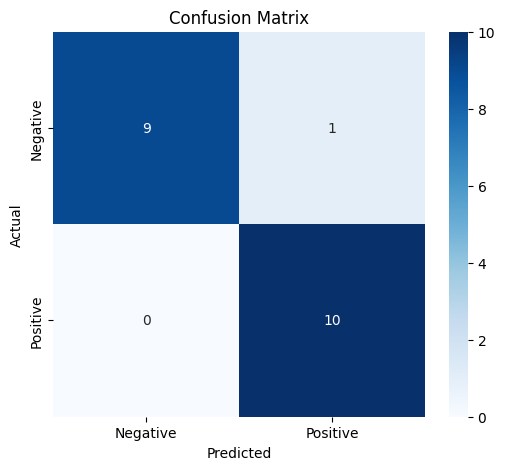

In [103]:
# --- Compute Evaluation Metrics ---

# Calculate accuracy on the test set.
accuracy  = accuracy_score(y_test, y_pred_loaded)

# Calculate precision for the positive class (label = 1).
precision = precision_score(y_test, y_pred_loaded, average='weighted')

# Calculate recall for the positive class (label = 1).
recall    = recall_score(y_test, y_pred_loaded, average='weighted')

# Calculate F1-score for the positive class (label = 1).
f1        = f1_score(y_test, y_pred_loaded, average='weighted')

# Combine all metrics into a single DataFrame for easier display.
metrics_df = pd.DataFrame(
    {
        'Accuracy':  [accuracy],
        'Precision': [precision],
        'Recall':    [recall],
        'F1-Score':  [f1]
    }
)

# Display the evaluation metrics as a table (nice HTML table in Jupyter/Colab).
print("\nEvaluation Metrics:")
display(metrics_df)


# --- Confusion Matrix ---

# Create the confusion matrix from actual vs predicted labels.
conf_matrix = confusion_matrix(y_test, y_pred_loaded)

# Put it into a DataFrame for readable row/column labels.
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

# Display the confusion matrix as a table.
print("\nConfusion Matrix Table:")
display(conf_matrix_df)


# --- Plot the Confusion Matrix as a Heatmap ---

plt.figure(figsize=(6,5))  # Set the figure size.
sns.heatmap(
    conf_matrix,
    annot=True, fmt='d', cmap='Blues',             # Show counts inside cells.
    xticklabels=['Negative', 'Positive'],           # X-axis tick labels.
    yticklabels=['Negative', 'Positive']            # Y-axis tick labels.
)
plt.xlabel('Predicted')                            # Label the x-axis.
plt.ylabel('Actual')                               # Label the y-axis.
plt.title('Confusion Matrix')                      # Title of the plot.
plt.show()

In [104]:
data

,Article,Heading,NewsType,Full_Text
0,strong>ISLAMABAD: The government has increased...,Petrol prices hiked by Rs171 per litr,business,Petrol prices hiked by Rs171 per litr strong>I...
1,ISLAMABAD: National Electric Power Regulatory ...,nepra approves rs2.88 per unit cut in power ta...,business,nepra approves rs2.88 per unit cut in power ta...
2,strong>Grocery shopping can be fun or a chore ...,Three ways to make grocery shopping easy,business,Three ways to make grocery shopping easy stron...
3,strong>NEW YORK/LONDON: Oil prices rose on Thu...,Oil ends 2015 down 35 per,business,Oil ends 2015 down 35 per strong>NEW YORK/LOND...
4,strong>KARACHI: Pakistan Stock Exchange witnes...,Pakistan Stock Exchange crosses 50000 points f...,business,Pakistan Stock Exchange crosses 50000 points f...
